# 🏥 Système d'aide au tri radiologique
**Projet Deep Learning — ChestMNIST 64px — PyTorch**

## Structure du notebook
1. Setup & Google Drive
2. Installation & imports
3. Chargement des données (ChestMNIST 64px)
4. EDA — Analyse exploratoire
5. Préparation des données
6. MLflow — Configuration
7. Modèle 1 — CNN from scratch
8. Modèle 2 — ResNet50 Transfer Learning
9. Modèle 3 — Vision Transformer (ViT)
10. Évaluation comparative
11. Détection d'anomalies — Autoencoder
12. Multimodal — NIH Chest X-Ray (image + texte)
13. Résumé MLflow

## 1. 📁 Montage Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Drive : UNIQUEMENT pour sauvegarder les résultats (modèles, figures, mlruns)
DRIVE_DIR = '/content/drive/MyDrive/projet_radiologie'
for folder in ['models', 'mlruns', 'figures']:
    os.makedirs(f'{DRIVE_DIR}/{folder}', exist_ok=True)

# Données : stockées localement dans Colab (re-téléchargées à chaque session, rapide)
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

# BASE_DIR pointe vers Drive pour tout ce qui est résultats
BASE_DIR = DRIVE_DIR

print('✅ Structure prête')
print(f'   Données  → {DATA_DIR}  (local Colab, ~200 Mo, re-téléchargé chaque session)')
print(f'   Modèles  → {DRIVE_DIR}/models  (persistant sur Drive)')
print(f'   MLflow   → {DRIVE_DIR}/mlruns  (persistant sur Drive)')
print(f'   Figures  → {DRIVE_DIR}/figures (persistant sur Drive)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Structure prête
   Données  → /content/data  (local Colab, ~200 Mo, re-téléchargé chaque session)
   Modèles  → /content/drive/MyDrive/projet_radiologie/models  (persistant sur Drive)
   MLflow   → /content/drive/MyDrive/projet_radiologie/mlruns  (persistant sur Drive)
   Figures  → /content/drive/MyDrive/projet_radiologie/figures (persistant sur Drive)


## 2. 📦 Installation & Imports

In [2]:
!pip install medmnist mlflow timm -q
print('✅ Packages installés')

✅ Packages installés


In [3]:
!pip install torch torchvision --upgrade -q

In [4]:
# ── Fix conflit torch/torchvision ──
import importlib, sys

# On retire les modules déjà chargés pour forcer un rechargement propre
for mod in list(sys.modules.keys()):
    if 'torch' in mod or 'torchvision' in mod:
        del sys.modules[mod]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
import seaborn as sns
import os, random, time, json
from pathlib import Path
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import (
    roc_auc_score, f1_score, average_precision_score,
    classification_report, confusion_matrix
)
import mlflow
import mlflow.pytorch
import medmnist
from medmnist import ChestMNIST, INFO
import timm

# ── Seed fixe pour reproductibilité ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports OK | Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')

✅ Imports OK | Device : cuda
   GPU : Tesla T4


## 3. 📊 Chargement ChestMNIST 64px

In [5]:
# ── Infos dataset ──
info = INFO['chestmnist']
N_CLASSES = len(info['label'])
CLASS_NAMES = list(info['label'].values())
print(f'Classes ({N_CLASSES}) : {CLASS_NAMES}')

# ── Transforms ──
IMG_SIZE = 64

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# ── Chargement dans /content/data (local Colab, pas Drive) ──
train_dataset = ChestMNIST(split='train', transform=transform_train, download=True, size=IMG_SIZE, root=DATA_DIR)
val_dataset   = ChestMNIST(split='val',   transform=transform_val,   download=True, size=IMG_SIZE, root=DATA_DIR)
test_dataset  = ChestMNIST(split='test',  transform=transform_val,   download=True, size=IMG_SIZE, root=DATA_DIR)

print(f'Train : {len(train_dataset):,} | Val : {len(val_dataset):,} | Test : {len(test_dataset):,}')
print(f'✅ Données stockées dans : {DATA_DIR} (local Colab)')

Classes (14) : ['atelectasis', 'cardiomegaly', 'effusion', 'infiltration', 'mass', 'nodule', 'pneumonia', 'pneumothorax', 'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia']


100%|██████████| 402M/402M [00:31<00:00, 12.9MB/s]


Train : 78,468 | Val : 11,219 | Test : 22,433
✅ Données stockées dans : /content/data (local Colab)


## 4. 🔍 EDA — Analyse Exploratoire

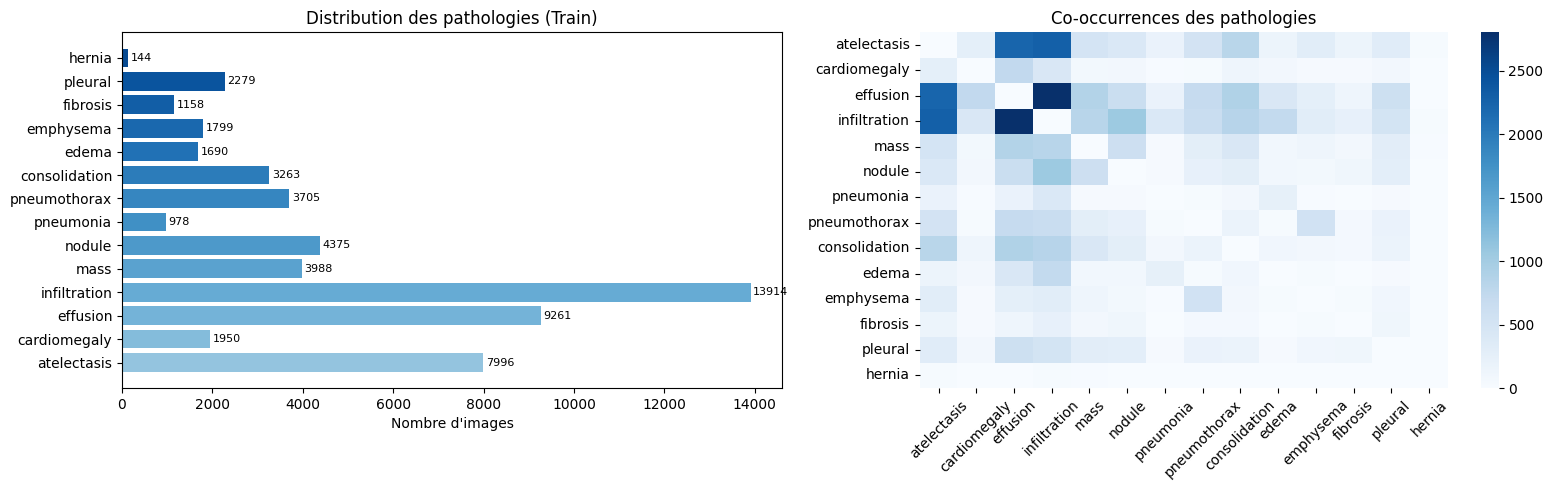

Déséquilibre max/min : 13914 vs 144


In [6]:
# ── Distribution des classes ──
train_labels = np.array([train_dataset[i][1] for i in range(len(train_dataset))])
class_counts = train_labels.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot distribution
ax = axes[0]
bars = ax.barh(CLASS_NAMES, class_counts, color=plt.cm.Blues(np.linspace(0.4, 0.9, N_CLASSES)))
ax.set_xlabel('Nombre d\'images')
ax.set_title('Distribution des pathologies (Train)')
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{int(count)}', va='center', fontsize=8)

# Co-occurrences
ax2 = axes[1]
cooc = train_labels.T @ train_labels
np.fill_diagonal(cooc, 0)
sns.heatmap(cooc, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', ax=ax2, fmt='d', annot=False)
ax2.set_title('Co-occurrences des pathologies')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Déséquilibre max/min : {int(class_counts.max())} vs {int(class_counts.min())}')

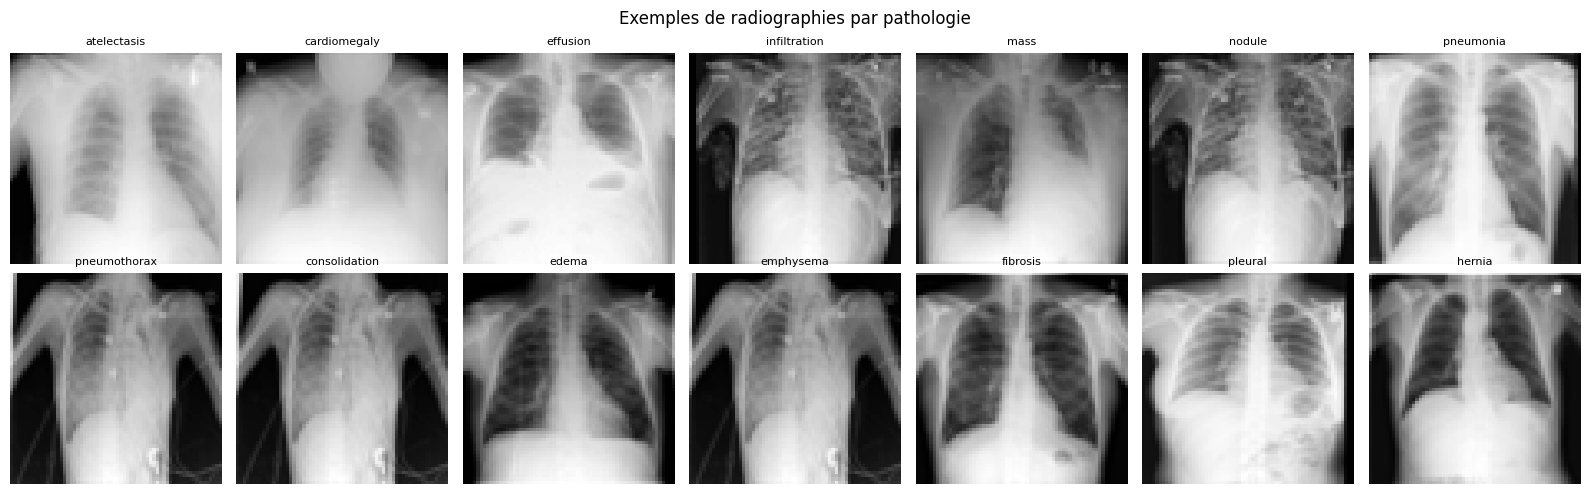

In [8]:
# ── Dataset sans normalisation pour visualiser ──
viz_dataset = ChestMNIST(split='train', transform=transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
]), download=False, size=IMG_SIZE, root=DATA_DIR)  # DATA_PATH → DATA_DIR

fig, axes = plt.subplots(2, 7, figsize=(16, 5))
axes = axes.flatten()

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    for i in range(len(viz_dataset)):
        img, label = viz_dataset[i]
        if label[cls_idx] == 1:
            axes[cls_idx].imshow(img.squeeze(), cmap='gray')
            axes[cls_idx].set_title(cls_name, fontsize=8)
            axes[cls_idx].axis('off')
            break

plt.suptitle('Exemples de radiographies par pathologie', fontsize=12)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/eda_exemples.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. ⚙️ Préparation des DataLoaders

In [9]:
# ── WeightedRandomSampler pour gérer le déséquilibre ──
label_array = np.array([train_dataset[i][1] for i in range(len(train_dataset))])
# Score de rareté : somme des labels rares
class_freq = label_array.sum(axis=0)
class_weights = 1.0 / (class_freq + 1)
sample_weights = (label_array * class_weights).sum(axis=1)
sample_weights = torch.DoubleTensor(sample_weights)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)

# ── Loss pondérée pour multi-label ──
pos_weight = torch.tensor(
    (len(train_dataset) - class_freq) / (class_freq + 1), dtype=torch.float
).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f'✅ DataLoaders prêts — Batch size : {BATCH_SIZE}')
print(f'   Batches train : {len(train_loader)} | val : {len(val_loader)} | test : {len(test_loader)}')

✅ DataLoaders prêts — Batch size : 64
   Batches train : 1227 | val : 176 | test : 351


## 6. 📈 Configuration MLflow

In [10]:
MLFLOW_DIR = f'{BASE_DIR}/mlruns'
mlflow.set_tracking_uri(f'file://{MLFLOW_DIR}')
mlflow.set_experiment('chest_radiologie')
print(f'✅ MLflow configuré → {MLFLOW_DIR}')

# ── Fonctions utilitaires ──
def compute_metrics(y_true, y_prob, threshold=0.5):
    """Calcule ROC-AUC, F1, PR-AUC pour multi-label."""
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {}
    try:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob, average='macro')
    except:
        metrics['roc_auc'] = 0.0
    metrics['f1_macro']  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['f1_micro']  = f1_score(y_true, y_pred, average='micro', zero_division=0)
    try:
        metrics['pr_auc'] = average_precision_score(y_true, y_prob, average='macro')
    except:
        metrics['pr_auc'] = 0.0
    return metrics

def evaluate_model(model, loader, criterion, device):
    """Évalue le modèle sur un loader, retourne loss + métriques."""
    model.eval()
    all_probs, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())
    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)
    metrics = compute_metrics(y_true, y_prob)
    metrics['loss'] = total_loss / len(loader)
    return metrics, y_true, y_prob

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                n_epochs, model_name, device):
    """Boucle d'entraînement avec MLflow tracking et early stopping."""
    best_auc = 0
    patience, patience_counter = 10, 0
    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_f1': []}

    with mlflow.start_run(run_name=model_name):
        # Log hyperparamètres
        mlflow.log_params({
            'model': model_name,
            'epochs': n_epochs,
            'batch_size': BATCH_SIZE,
            'optimizer': type(optimizer).__name__,
            'lr': optimizer.param_groups[0]['lr'],
            'img_size': IMG_SIZE,
            'seed': SEED
        })

        for epoch in range(n_epochs):
            # ── Train ──
            model.train()
            train_loss = 0
            for images, labels in tqdm(train_loader, desc=f'[{model_name}] Epoch {epoch+1}/{n_epochs}', leave=False):
                images = images.to(device)
                labels = labels.float().to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)

            # ── Validation ──
            val_metrics, _, _ = evaluate_model(model, val_loader, criterion, device)
            if scheduler:
                scheduler.step(val_metrics['roc_auc'])

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_metrics['loss'])
            history['val_auc'].append(val_metrics['roc_auc'])
            history['val_f1'].append(val_metrics['f1_macro'])

            # Log MLflow
            mlflow.log_metrics({
                'train_loss': train_loss,
                'val_loss': val_metrics['loss'],
                'val_roc_auc': val_metrics['roc_auc'],
                'val_f1_macro': val_metrics['f1_macro'],
                'val_pr_auc': val_metrics['pr_auc']
            }, step=epoch)

            print(f'  Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | '
                  f'Val Loss: {val_metrics["loss"]:.4f} | '
                  f'ROC-AUC: {val_metrics["roc_auc"]:.4f} | '
                  f'F1: {val_metrics["f1_macro"]:.4f}')

            # ── Sauvegarde meilleur modèle ──
            if val_metrics['roc_auc'] > best_auc:
                best_auc = val_metrics['roc_auc']
                patience_counter = 0
                save_path = f'{BASE_DIR}/models/{model_name}_best.pth'
                torch.save(model.state_dict(), save_path)
                mlflow.log_artifact(save_path)
                print(f'  💾 Meilleur modèle sauvegardé (AUC={best_auc:.4f})')
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f'  ⏹ Early stopping à l\'epoch {epoch+1}')
                    break

        mlflow.log_metric('best_val_roc_auc', best_auc)

        # ── Courbes d'apprentissage ──
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].plot(history['train_loss'], label='Train')
        axes[0].plot(history['val_loss'],   label='Val')
        axes[0].set_title(f'{model_name} — Loss')
        axes[0].legend(); axes[0].set_xlabel('Epoch')
        axes[1].plot(history['val_auc'])
        axes[1].set_title(f'{model_name} — ROC-AUC val')
        axes[1].set_xlabel('Epoch')
        axes[2].plot(history['val_f1'])
        axes[2].set_title(f'{model_name} — F1 macro val')
        axes[2].set_xlabel('Epoch')
        plt.tight_layout()
        fig_path = f'{BASE_DIR}/figures/{model_name}_curves.png'
        plt.savefig(fig_path, dpi=150)
        mlflow.log_artifact(fig_path)
        plt.show()

    return history, best_auc

print('✅ Fonctions utilitaires prêtes')

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/27 20:47:44 INFO mlflow.tracking.fluent: Experiment with name 'chest_radiologie' does not exist. Creating a new experiment.


✅ MLflow configuré → /content/drive/MyDrive/projet_radiologie/mlruns
✅ Fonctions utilitaires prêtes


## 7. 🧠 Modèle 1 — CNN from Scratch

✅ CNN from scratch | Paramètres : 323,950

🚀 Entraînement CNN from scratch...


  Epoch 01 | Train Loss: 2.2771 | Val Loss: 1.8033 | ROC-AUC: 0.6267 | F1: 0.0932
  💾 Meilleur modèle sauvegardé (AUC=0.6267)


  Epoch 02 | Train Loss: 2.2225 | Val Loss: 1.7514 | ROC-AUC: 0.6390 | F1: 0.0952
  💾 Meilleur modèle sauvegardé (AUC=0.6390)


  Epoch 03 | Train Loss: 2.2110 | Val Loss: 1.7795 | ROC-AUC: 0.6310 | F1: 0.0933


  Epoch 04 | Train Loss: 2.1966 | Val Loss: 1.7889 | ROC-AUC: 0.6393 | F1: 0.0932
  💾 Meilleur modèle sauvegardé (AUC=0.6393)


...

  Epoch 16 | Train Loss: 2.0381 | Val Loss: 1.7277 | ROC-AUC: 0.7049 | F1: 0.0968
  💾 Meilleur modèle sauvegardé (AUC=0.7049)


  Epoch 17 | Train Loss: 2.0291 | Val Loss: 1.6602 | ROC-AUC: 0.6978 | F1: 0.0981


  Epoch 18 | Train Loss: 2.0102 | Val Loss: 1.6360 | ROC-AUC: 0.6991 | F1: 0.0950


  Epoch 19 | Train Loss: 1.9966 | Val Loss: 1.6556 | ROC-AUC: 0.7091 | F1: 0.0987
  💾 Meilleur modèle sauvegardé (AUC=0.7091)


  Epoch 20 | Train Loss: 1.9872 | Val Loss: 1.6454 | ROC-AUC: 0.7067 | F1: 0.0982


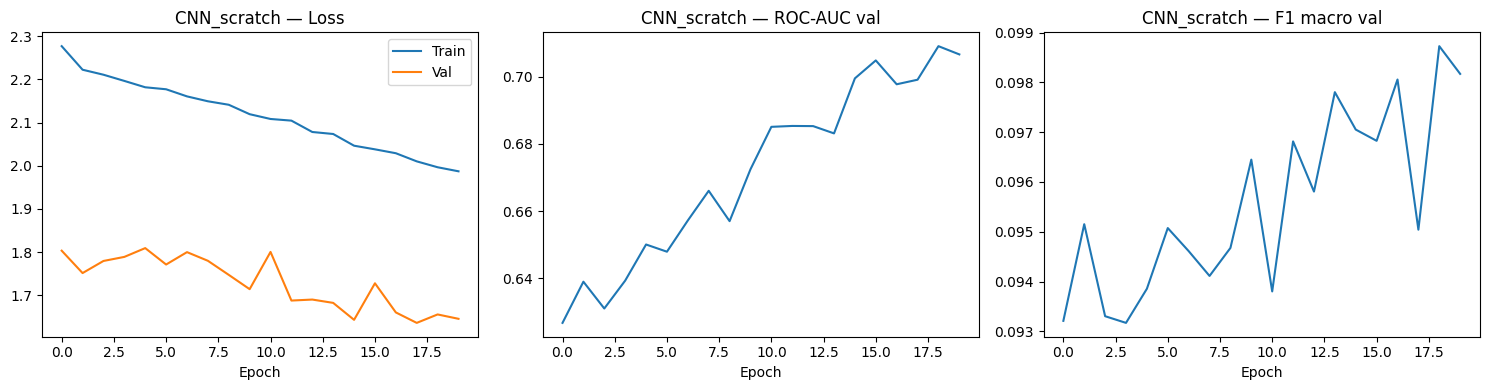

✅ CNN terminé | Meilleur ROC-AUC val : 0.7091


In [12]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=14):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = SimpleCNN(N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'✅ CNN from scratch | Paramètres : {total_params:,}')

optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_cnn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, 'max', patience=3, factor=0.5)  # verbose supprimé

print('\n🚀 Entraînement CNN from scratch...')
history_cnn, best_auc_cnn = train_model(
    cnn_model, train_loader, val_loader, criterion,
    optimizer_cnn, scheduler_cnn,
    n_epochs=20, model_name='CNN_scratch', device=DEVICE
)
print(f'✅ CNN terminé | Meilleur ROC-AUC val : {best_auc_cnn:.4f}')

## 8. 🔄 Modèle 2 — ResNet50 Transfer Learning

✅ ResNet50 | Paramètres entraînables : 16,021,006

🚀 Entraînement ResNet50 (phase 1 — head)...


  Epoch 01 | Train Loss: 2.1894 | Val Loss: 1.6866 | ROC-AUC: 0.6655 | F1: 0.0969
  💾 Meilleur modèle sauvegardé (AUC=0.6655)


  Epoch 02 | Train Loss: 2.0906 | Val Loss: 1.6639 | ROC-AUC: 0.6688 | F1: 0.0988
  💾 Meilleur modèle sauvegardé (AUC=0.6688)


  Epoch 03 | Train Loss: 2.0473 | Val Loss: 1.6712 | ROC-AUC: 0.6696 | F1: 0.0981
  💾 Meilleur modèle sauvegardé (AUC=0.6696)


  Epoch 04 | Train Loss: 2.0139 | Val Loss: 1.6398 | ROC-AUC: 0.6689 | F1: 0.0994


...

  Epoch 11 | Train Loss: 1.9095 | Val Loss: 1.6998 | ROC-AUC: 0.6816 | F1: 0.0981


  Epoch 12 | Train Loss: 1.8973 | Val Loss: 1.6574 | ROC-AUC: 0.6839 | F1: 0.0995
  💾 Meilleur modèle sauvegardé (AUC=0.6839)


  Epoch 13 | Train Loss: 1.8874 | Val Loss: 1.6772 | ROC-AUC: 0.6882 | F1: 0.0993
  💾 Meilleur modèle sauvegardé (AUC=0.6882)


  Epoch 14 | Train Loss: 1.8913 | Val Loss: 1.6947 | ROC-AUC: 0.6806 | F1: 0.1003


  Epoch 15 | Train Loss: 1.8899 | Val Loss: 1.6514 | ROC-AUC: 0.6869 | F1: 0.1009


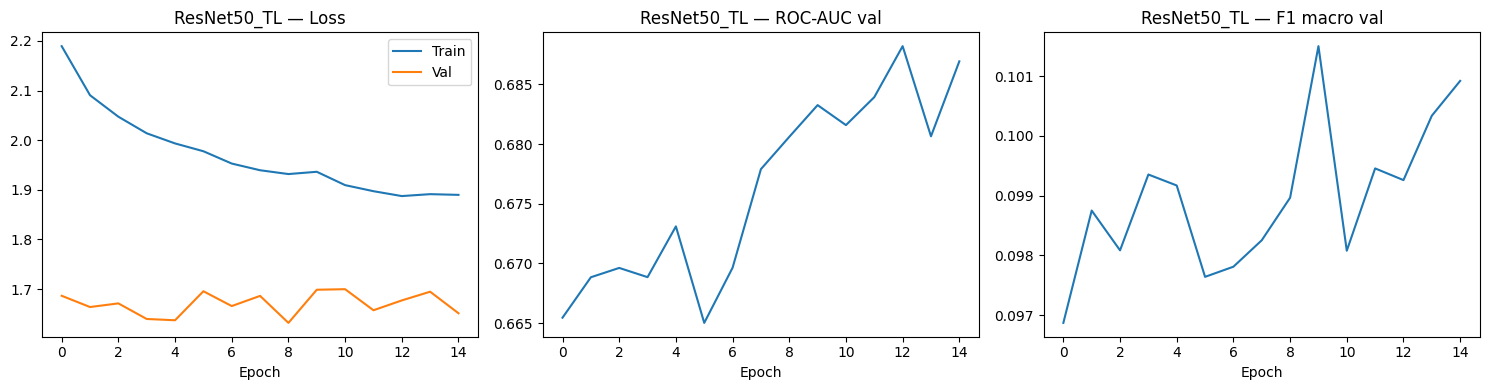


🔓 Dégel du backbone pour fine-tuning complet...


/tmp/ipykernel_7897/2489264814.py:81: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_metrics['roc_auc'])


  Epoch 01 | Train Loss: 1.8494 | Val Loss: 1.6843 | ROC-AUC: 0.6955 | F1: 0.1038
  💾 Meilleur modèle sauvegardé (AUC=0.6955)


/tmp/ipykernel_7897/2489264814.py:81: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_metrics['roc_auc'])


  Epoch 02 | Train Loss: 1.7800 | Val Loss: 1.7978 | ROC-AUC: 0.6882 | F1: 0.1009


...

  Epoch 13 | Train Loss: 1.2792 | Val Loss: 2.1954 | ROC-AUC: 0.7020 | F1: 0.1182


/tmp/ipykernel_7897/2489264814.py:81: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_metrics['roc_auc'])


  Epoch 14 | Train Loss: 1.2017 | Val Loss: 2.2403 | ROC-AUC: 0.6931 | F1: 0.1181


/tmp/ipykernel_7897/2489264814.py:81: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_metrics['roc_auc'])


  Epoch 15 | Train Loss: 1.2179 | Val Loss: 1.9326 | ROC-AUC: 0.6997 | F1: 0.1190


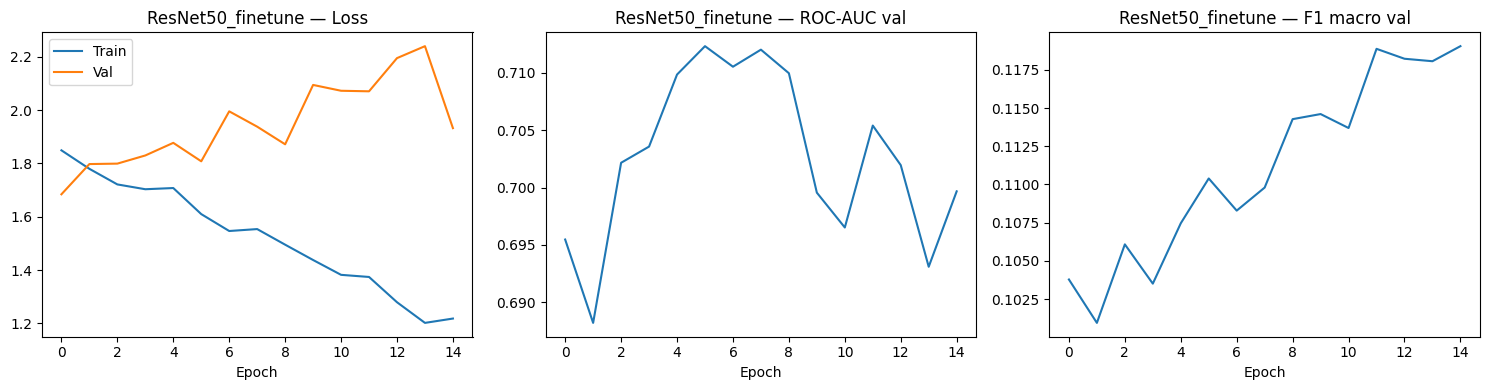

✅ ResNet50 terminé | Meilleur ROC-AUC val : 0.7123


In [14]:
class ResNetChest(nn.Module):
    def __init__(self, n_classes=14, freeze_backbone=True):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if freeze_backbone:
            for name, param in self.backbone.named_parameters():
                if 'layer4' not in name and 'fc' not in name:
                    param.requires_grad = False
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):
        return self.backbone(x)

resnet_model = ResNetChest(N_CLASSES).to(DEVICE)
trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f'✅ ResNet50 | Paramètres entraînables : {trainable:,}')

# Phase 1 : fine-tune head uniquement
optimizer_res = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler_res = optim.lr_scheduler.ReduceLROnPlateau(optimizer_res, 'max', patience=3, factor=0.5)

print('\n🚀 Entraînement ResNet50 (phase 1 — head)...')
history_res, best_auc_res = train_model(
    resnet_model, train_loader, val_loader, criterion,
    optimizer_res, scheduler_res,
    n_epochs=15, model_name='ResNet50_TL', device=DEVICE
)

# Phase 2 : dégel complet
print('\n🔓 Dégel du backbone pour fine-tuning complet...')
for param in resnet_model.parameters():
    param.requires_grad = True
optimizer_res2 = optim.Adam(resnet_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_res2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_res2, T_max=10)

history_res2, best_auc_res2 = train_model(
    resnet_model, train_loader, val_loader, criterion,
    optimizer_res2, scheduler_res2,
    n_epochs=15, model_name='ResNet50_finetune', device=DEVICE
)
best_auc_res = max(best_auc_res, best_auc_res2)
print(f'✅ ResNet50 terminé | Meilleur ROC-AUC val : {best_auc_res:.4f}')

## 9. 🤖 Modèle 3 — Vision Transformer (ViT)

In [15]:
class ViTChest(nn.Module):
    def __init__(self, n_classes=14):
        super().__init__()
        self.vit = timm.create_model(
            'vit_small_patch16_224',
            pretrained=True,
            num_classes=0,
            in_chans=1
        )
        embed_dim = self.vit.embed_dim
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(0.4),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
        # Geler tout sauf les 2 derniers blocs et la head
        for name, param in self.vit.named_parameters():
            if not any(x in name for x in ['blocks.10', 'blocks.11', 'norm']):
                param.requires_grad = False

    def forward(self, x):
        # Redimensionner pour ViT (attend 224x224)
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        features = self.vit(x)
        return self.head(features)

vit_model = ViTChest(N_CLASSES).to(DEVICE)
trainable_vit = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'✅ ViT Small | Paramètres entraînables : {trainable_vit:,}')

optimizer_vit = optim.AdamW(
    filter(lambda p: p.requires_grad, vit_model.parameters()),
    lr=5e-5, weight_decay=0.05
)
scheduler_vit = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_vit, T_0=10)

print('\n🚀 Entraînement ViT...')
history_vit, best_auc_vit = train_model(
    vit_model, train_loader, val_loader, criterion,
    optimizer_vit, scheduler_vit,
    n_epochs=20, model_name='ViT_small', device=DEVICE
)
print(f'✅ ViT terminé | Meilleur ROC-AUC val : {best_auc_vit:.4f}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

✅ ViT Small | Paramètres entraînables : 3,667,982

🚀 Entraînement ViT...


  Epoch 01 | Train Loss: 2.1889 | Val Loss: 1.6494 | ROC-AUC: 0.7005 | F1: 0.0982
  💾 Meilleur modèle sauvegardé (AUC=0.7005)


  Epoch 02 | Train Loss: 1.9622 | Val Loss: 1.5591 | ROC-AUC: 0.7192 | F1: 0.1032
  💾 Meilleur modèle sauvegardé (AUC=0.7192)


...

  Epoch 08 | Train Loss: 1.5270 | Val Loss: 1.6546 | ROC-AUC: 0.7165 | F1: 0.1140


  Epoch 09 | Train Loss: 1.4804 | Val Loss: 1.6757 | ROC-AUC: 0.7131 | F1: 0.1163


  Epoch 10 | Train Loss: 1.4185 | Val Loss: 1.6259 | ROC-AUC: 0.7147 | F1: 0.1188


  Epoch 11 | Train Loss: 1.3686 | Val Loss: 1.5920 | ROC-AUC: 0.7129 | F1: 0.1185


KeyboardInterrupt: 

## 10. 📊 Évaluation comparative sur le test set

In [16]:
results = {}

for model_name, model, best_path in [
    ('CNN_scratch',      cnn_model,    f'{BASE_DIR}/models/CNN_scratch_best.pth'),
    ('ResNet50_TL',      resnet_model, f'{BASE_DIR}/models/ResNet50_finetune_best.pth'),
    ('ViT_small',        vit_model,    f'{BASE_DIR}/models/ViT_small_best.pth'),
]:
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    metrics, y_true, y_prob = evaluate_model(model, test_loader, criterion, DEVICE)
    results[model_name] = {'metrics': metrics, 'y_true': y_true, 'y_prob': y_prob}
    print(f'{model_name:20s} | ROC-AUC: {metrics["roc_auc"]:.4f} | F1: {metrics["f1_macro"]:.4f} | PR-AUC: {metrics["pr_auc"]:.4f}')

# ── Tableau comparatif ──
print('\n── Résumé comparatif (Test Set) ──')
df_results = pd.DataFrame({
    name: {
        'ROC-AUC': f"{v['metrics']['roc_auc']:.4f}",
        'F1 macro': f"{v['metrics']['f1_macro']:.4f}",
        'PR-AUC': f"{v['metrics']['pr_auc']:.4f}"
    } for name, v in results.items()
}).T
print(df_results)
df_results.to_csv(f'{BASE_DIR}/figures/resultats_comparatifs.csv')

CNN_scratch          | ROC-AUC: 0.7046 | F1: 0.1019 | PR-AUC: 0.1187
ResNet50_TL          | ROC-AUC: 0.7154 | F1: 0.1146 | PR-AUC: 0.1278
ViT_small            | ROC-AUC: 0.7190 | F1: 0.1140 | PR-AUC: 0.1331

── Résumé comparatif (Test Set) ──
            ROC-AUC F1 macro  PR-AUC
CNN_scratch  0.7046   0.1019  0.1187
ResNet50_TL  0.7154   0.1146  0.1278
ViT_small    0.7190   0.1140  0.1331


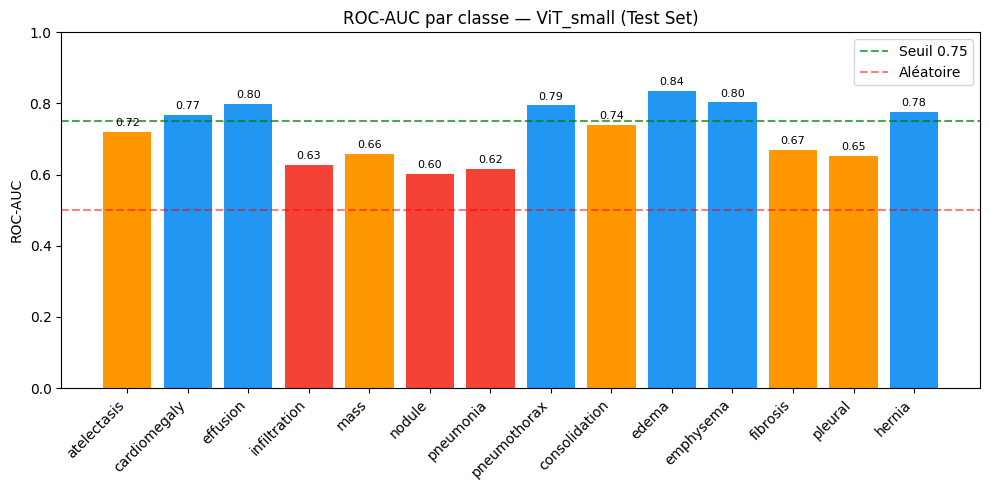

In [17]:
# ── ROC-AUC par classe pour le meilleur modèle ──
best_model_name = max(results, key=lambda k: results[k]['metrics']['roc_auc'])
y_true_best = results[best_model_name]['y_true']
y_prob_best = results[best_model_name]['y_prob']

per_class_auc = [
    roc_auc_score(y_true_best[:, i], y_prob_best[:, i])
    for i in range(N_CLASSES)
]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3' if auc >= 0.75 else '#FF9800' if auc >= 0.65 else '#F44336'
          for auc in per_class_auc]
bars = ax.bar(CLASS_NAMES, per_class_auc, color=colors)
ax.axhline(0.75, color='green', linestyle='--', alpha=0.7, label='Seuil 0.75')
ax.axhline(0.5,  color='red',   linestyle='--', alpha=0.5, label='Aléatoire')
ax.set_ylim(0, 1)
ax.set_ylabel('ROC-AUC')
ax.set_title(f'ROC-AUC par classe — {best_model_name} (Test Set)')
ax.legend()
plt.xticks(rotation=45, ha='right')
for bar, auc in zip(bars, per_class_auc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{auc:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/roc_auc_par_classe.png', dpi=150)
plt.show()

## 11. 🔬 Détection d'anomalies — Autoencoder Convolutionnel

✅ Autoencoder | Paramètres : 332,865


  AE Epoch 01 | Loss: 0.019931


  AE Epoch 02 | Loss: 0.006916


  AE Epoch 03 | Loss: 0.005452


  AE Epoch 04 | Loss: 0.004608


...

  AE Epoch 16 | Loss: 0.002101


  AE Epoch 17 | Loss: 0.002043


  AE Epoch 18 | Loss: 0.001985


  AE Epoch 19 | Loss: 0.001943


  AE Epoch 20 | Loss: 0.001899
💾 Autoencoder sauvegardé sur Drive


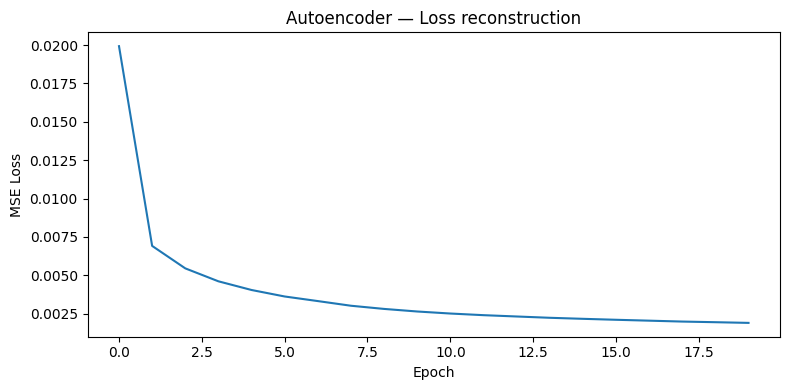

✅ Autoencoder entraîné


In [18]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),   # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 8x8
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, stride=2, padding=1), # 4x4
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 128, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def get_anomaly_score(self, x):
        recon = self.forward(x)
        return F.mse_loss(recon, x, reduction='none').mean(dim=[1,2,3])

ae_model = ConvAutoencoder().to(DEVICE)
print(f'✅ Autoencoder | Paramètres : {sum(p.numel() for p in ae_model.parameters()):,}')

ae_optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)
ae_criterion = nn.MSELoss()
ae_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

N_EPOCHS_AE = 20
ae_losses = []

with mlflow.start_run(run_name='ConvAutoencoder'):
    mlflow.log_params({'epochs': N_EPOCHS_AE, 'lr': 1e-3, 'model': 'ConvAutoencoder'})

    for epoch in range(N_EPOCHS_AE):
        ae_model.train()
        epoch_loss = 0
        for images, _ in tqdm(ae_train_loader, desc=f'AE Epoch {epoch+1}/{N_EPOCHS_AE}', leave=False):
            images = images.to(DEVICE)
            recon = ae_model(images)
            loss = ae_criterion(recon, images)
            ae_optimizer.zero_grad()
            loss.backward()
            ae_optimizer.step()
            epoch_loss += loss.item()
        epoch_loss /= len(ae_train_loader)
        ae_losses.append(epoch_loss)
        mlflow.log_metric('train_loss', epoch_loss, step=epoch)
        print(f'  AE Epoch {epoch+1:02d} | Loss: {epoch_loss:.6f}')

    ae_path = f'{BASE_DIR}/models/autoencoder_best.pth'
    torch.save(ae_model.state_dict(), ae_path)
    mlflow.log_artifact(ae_path)
    print(f'💾 Autoencoder sauvegardé sur Drive')

# Courbe de loss
plt.figure(figsize=(8, 4))
plt.plot(ae_losses)
plt.title('Autoencoder — Loss reconstruction')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/ae_loss.png', dpi=150)
plt.show()
print('✅ Autoencoder entraîné')

Scores d'anomalie | Min: 0.0001 | Max: 0.0064 | Mean: 0.0013


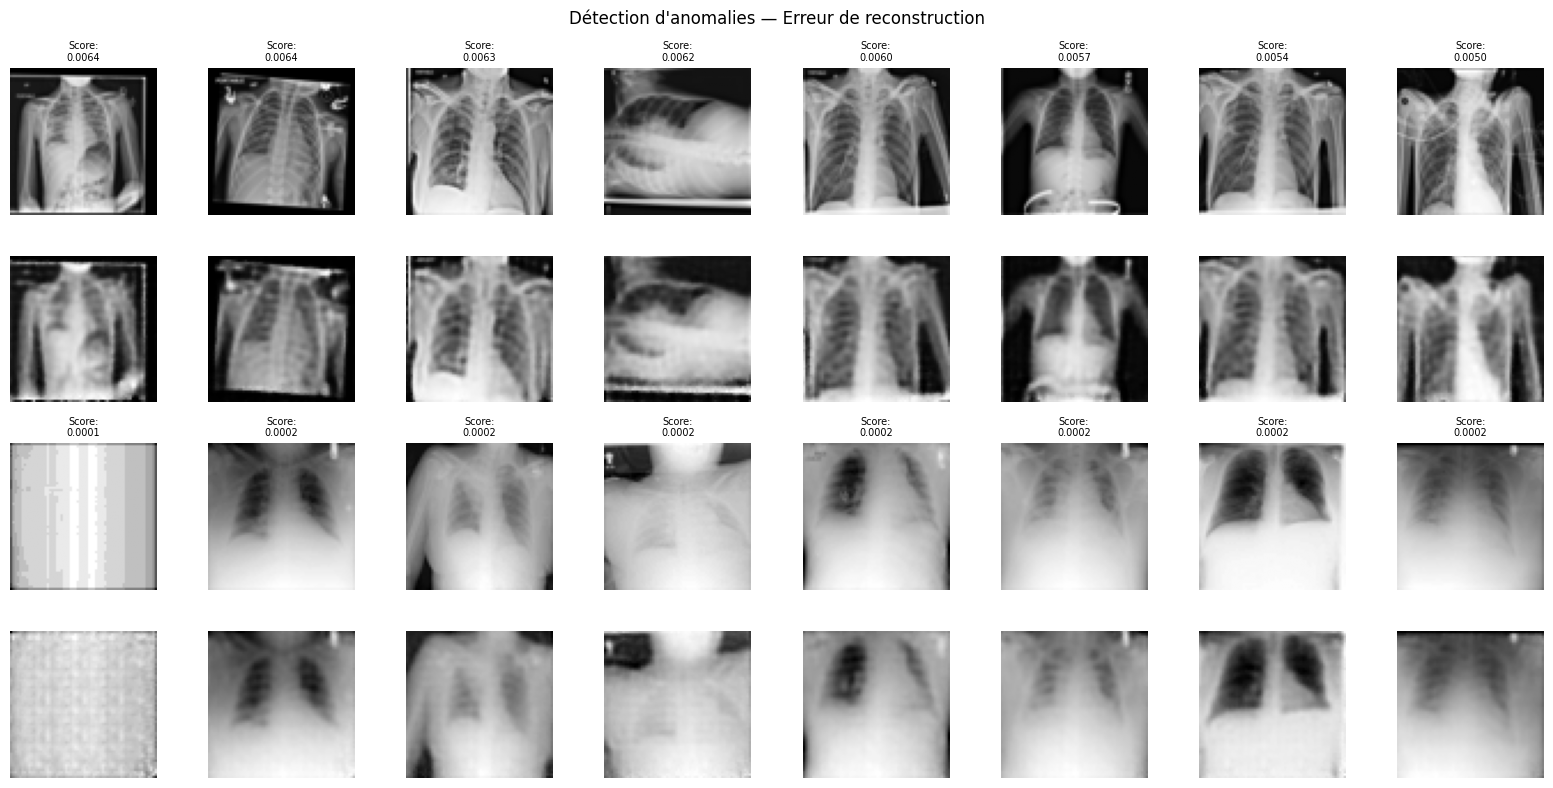

In [19]:
# ── Calcul des scores d'anomalie sur le test set ──
ae_model.eval()
all_scores, all_images_orig, all_images_recon = [], [], []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        scores = ae_model.get_anomaly_score(images)
        recon  = ae_model(images)
        all_scores.extend(scores.cpu().numpy())
        all_images_orig.extend(images.cpu().numpy())
        all_images_recon.extend(recon.cpu().numpy())

all_scores = np.array(all_scores)
print(f'Scores d\'anomalie | Min: {all_scores.min():.4f} | Max: {all_scores.max():.4f} | Mean: {all_scores.mean():.4f}')

# ── Visualisation des cas les plus atypiques ──
top_k = 8
top_indices = np.argsort(all_scores)[-top_k:][::-1]  # Les plus anormaux
low_indices  = np.argsort(all_scores)[:top_k]          # Les plus normaux

fig, axes = plt.subplots(4, top_k, figsize=(16, 8))
for col, idx in enumerate(top_indices):
    axes[0, col].imshow(all_images_orig[idx].squeeze(), cmap='gray')
    axes[0, col].set_title(f'Score:\n{all_scores[idx]:.4f}', fontsize=7)
    axes[0, col].axis('off')
    axes[1, col].imshow(all_images_recon[idx].squeeze(), cmap='gray')
    axes[1, col].axis('off')

for col, idx in enumerate(low_indices):
    axes[2, col].imshow(all_images_orig[idx].squeeze(), cmap='gray')
    axes[2, col].set_title(f'Score:\n{all_scores[idx]:.4f}', fontsize=7)
    axes[2, col].axis('off')
    axes[3, col].imshow(all_images_recon[idx].squeeze(), cmap='gray')
    axes[3, col].axis('off')

axes[0, 0].set_ylabel('Originaux\n(atypiques)', fontsize=9)
axes[1, 0].set_ylabel('Reconstructions\n(atypiques)', fontsize=9)
axes[2, 0].set_ylabel('Originaux\n(normaux)', fontsize=9)
axes[3, 0].set_ylabel('Reconstructions\n(normaux)', fontsize=9)
plt.suptitle('Détection d\'anomalies — Erreur de reconstruction', fontsize=12)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/anomalie_visualisation.png', dpi=150)
plt.show()

## 12. 🔀 Multimodal — Image + Texte (NIH Chest X-Ray)

In [ ]:
# ── Dataset multimodal simplifié avec les labels textuels de ChestMNIST ──
# Note : pour le vrai NIH dataset, remplacer par les vrais comptes-rendus
# Ici on simule les annotations textuelles à partir des labels

PATHOLOGY_TEXTS = {
    0: 'atelectasis pulmonary collapse',
    1: 'cardiomegaly enlarged heart',
    2: 'effusion pleural fluid',
    3: 'infiltration lung infiltrate',
    4: 'mass lung nodule tumor',
    5: 'nodule pulmonary nodule',
    6: 'pneumonia infection inflammation',
    7: 'pneumothorax collapsed lung air',
    8: 'consolidation lung consolidation',
    9: 'edema pulmonary edema fluid',
    10: 'emphysema hyperinflation obstructive',
    11: 'fibrosis pulmonary fibrosis scarring',
    12: 'pleural thickening pleural disease',
    13: 'hernia diaphragmatic hernia'
}

class MultimodalChestDataset(Dataset):
    def __init__(self, base_dataset, vocab=None, max_len=20):
        self.base = base_dataset
        self.max_len = max_len
        # Construction vocabulaire
        all_words = set()
        for text in PATHOLOGY_TEXTS.values():
            all_words.update(text.split())
        all_words.add('normal')
        all_words.add('<pad>')
        self.vocab = vocab or {w: i+2 for i, w in enumerate(sorted(all_words))}
        self.vocab['<pad>'] = 0
        self.vocab['<unk>'] = 1

    def label_to_text(self, label):
        """Convertit un vecteur de labels en phrase descriptive."""
        active = [PATHOLOGY_TEXTS[i] for i in range(len(label)) if label[i] == 1]
        return ' '.join(active) if active else 'normal chest radiograph no finding'

    def tokenize(self, text):
        tokens = [self.vocab.get(w, 1) for w in text.split()[:self.max_len]]
        tokens += [0] * (self.max_len - len(tokens))
        return torch.tensor(tokens, dtype=torch.long)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        text = self.label_to_text(label.numpy())
        tokens = self.tokenize(text)
        return img, tokens, label.float()

mm_train = MultimodalChestDataset(train_dataset)
mm_val   = MultimodalChestDataset(val_dataset,  vocab=mm_train.vocab)
mm_test  = MultimodalChestDataset(test_dataset, vocab=mm_train.vocab)
VOCAB_SIZE = len(mm_train.vocab)

mm_train_loader = DataLoader(mm_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
mm_val_loader   = DataLoader(mm_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
mm_test_loader  = DataLoader(mm_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'✅ Dataset multimodal | Vocab size : {VOCAB_SIZE}')

In [ ]:
# ── Modèle Texte seul ──
class TextOnlyModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden=128, n_classes=14, max_len=20):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x_img, x_text):
        emb = self.embedding(x_text)
        _, (hn, _) = self.lstm(emb)
        h = torch.cat([hn[0], hn[1]], dim=1)
        return self.fc(self.dropout(h))

# ── Modèle Image seule (CNN léger) ──
class ImageOnlyModel(nn.Module):
    def __init__(self, n_classes=14):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten()
        )
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, n_classes))

    def forward(self, x_img, x_text):
        return self.fc(self.cnn(x_img))

# ── Modèle Multimodal (Late Fusion) ──
class MultimodalModel(nn.Module):
    def __init__(self, vocab_size, n_classes=14):
        super().__init__()
        # Branche image
        self.img_branch = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten()
        )
        self.img_proj = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Dropout(0.3))

        # Branche texte
        self.embedding = nn.Embedding(vocab_size, 64, padding_idx=0)
        self.lstm = nn.LSTM(64, 64, batch_first=True, bidirectional=True)
        self.text_proj = nn.Sequential(nn.Linear(128, 128), nn.ReLU(), nn.Dropout(0.3))

        # Fusion (Late Fusion — concaténation)
        self.fusion = nn.Sequential(
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )

    def forward(self, x_img, x_text):
        img_feat  = self.img_proj(self.img_branch(x_img))
        emb = self.embedding(x_text)
        _, (hn, _) = self.lstm(emb)
        text_feat = self.text_proj(torch.cat([hn[0], hn[1]], dim=1))
        fused = torch.cat([img_feat, text_feat], dim=1)
        return self.fusion(fused)

def train_multimodal(model, train_loader, val_loader, criterion, optimizer,
                     n_epochs, run_name, device):
    best_auc, history = 0, []
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({'model': run_name, 'epochs': n_epochs})
        for epoch in range(n_epochs):
            model.train()
            train_loss = 0
            for imgs, texts, labels in tqdm(train_loader, desc=f'[{run_name}] {epoch+1}/{n_epochs}', leave=False):
                imgs, texts, labels = imgs.to(device), texts.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(imgs, texts)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            # Validation
            model.eval()
            all_probs, all_labels = [], []
            with torch.no_grad():
                for imgs, texts, labels in val_loader:
                    imgs, texts = imgs.to(device), texts.to(device)
                    probs = torch.sigmoid(model(imgs, texts)).cpu().numpy()
                    all_probs.append(probs)
                    all_labels.append(labels.numpy())
            y_prob = np.concatenate(all_probs)
            y_true = np.concatenate(all_labels)
            try:
                auc = roc_auc_score(y_true, y_prob, average='macro')
            except:
                auc = 0
            history.append(auc)
            mlflow.log_metric('val_roc_auc', auc, step=epoch)
            if auc > best_auc:
                best_auc = auc
                torch.save(model.state_dict(), f'{BASE_DIR}/models/{run_name}_best.pth')
            if (epoch+1) % 5 == 0:
                print(f'  {run_name} Epoch {epoch+1} | AUC: {auc:.4f}')
        mlflow.log_metric('best_val_roc_auc', best_auc)
    return best_auc

print('✅ Modèles multimodaux définis')

# ── Entraînement des 3 modèles ──
N_MM_EPOCHS = 20
mm_results = {}

for name, model_cls in [
    ('Image_only',  lambda: ImageOnlyModel(N_CLASSES)),
    ('Text_only',   lambda: TextOnlyModel(VOCAB_SIZE, n_classes=N_CLASSES)),
    ('Multimodal',  lambda: MultimodalModel(VOCAB_SIZE, N_CLASSES)),
]:
    print(f'\n🚀 Entraînement {name}...')
    m = model_cls().to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    best = train_multimodal(m, mm_train_loader, mm_val_loader, criterion, opt,
                            N_MM_EPOCHS, name, DEVICE)
    mm_results[name] = best
    print(f'✅ {name} | Best AUC: {best:.4f}')

print('\n── Comparaison Multimodale ──')
for k, v in mm_results.items():
    print(f'  {k:15s} : ROC-AUC = {v:.4f}')

## 13. 📋 Résumé MLflow & Sauvegarde finale

In [ ]:
# ── Récap de tous les runs MLflow ──
import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri=f'file://{MLFLOW_DIR}')
experiment = client.get_experiment_by_name('chest_radiologie')
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.best_val_roc_auc DESC']
)

print('═' * 70)
print(f'{"Run Name":25s} | {"ROC-AUC":>8s} | {"F1 Macro":>9s} | {"PR-AUC":>7s}')
print('─' * 70)
for run in runs:
    name   = run.data.tags.get('mlflow.runName', 'N/A')
    auc    = run.data.metrics.get('best_val_roc_auc', run.data.metrics.get('val_roc_auc', 0))
    f1     = run.data.metrics.get('val_f1_macro', 0)
    pr_auc = run.data.metrics.get('val_pr_auc', 0)
    print(f'{name:25s} | {auc:8.4f} | {f1:9.4f} | {pr_auc:7.4f}')
print('═' * 70)

print(f'\n✅ Tous les runs sont sauvegardés dans : {MLFLOW_DIR}')
print('💡 Pour visualiser MLflow UI en local :')
print(f'   mlflow ui --backend-store-uri file://{MLFLOW_DIR}')

In [ ]:
# ── Rapport final ──
print('\n' + '═'*60)
print('RAPPORT FINAL — SYSTÈME D\'AIDE AU TRI RADIOLOGIQUE')
print('═'*60)
print('\n📊 Classification supervisée (Test Set) :')
for name, data in results.items():
    m = data['metrics']
    print(f'  {name:20s} → AUC: {m["roc_auc"]:.4f} | F1: {m["f1_macro"]:.4f}')

print('\n🔬 Détection d\'anomalies :')
print(f'  Score moyen : {all_scores.mean():.4f} | Seuil 95e percentile : {np.percentile(all_scores, 95):.4f}')

print('\n🔀 Comparaison multimodale :')
for k, v in mm_results.items():
    print(f'  {k:15s} → AUC: {v:.4f}')

print('\n💾 Fichiers sauvegardés :')
for f in Path(f'{BASE_DIR}/models').glob('*.pth'):
    print(f'  {f.name}')
print('═'*60)